In [31]:
import pandas as pd
import numpy as np

In [32]:
df_pay = pd.read_csv("data/03 Оплаты ХК.csv", sep=";")

In [ ]:
from form_time_features import calculate_complex_features, calculate_complex_features_actions_based, actions_features_dateless,

In [33]:
from general_information import read_actions, read_balances, read_payments
actions = read_actions()
payments = read_payments()
balance = read_balances()
balance = balance[balance["ЛС"].notna()]


In [34]:
df_pay.head()

,Номер,Дата оплаты,Сумма,Способ оплаты
0,15,24.01.2025,100,5.0
1,15,25.01.2026,1240,5.0
2,15,25.05.2025,"293,96",5.0
3,15,25.06.2025,10,5.0
4,15,26.02.2025,"289,56",5.0


In [35]:
df_pay.groupby(by="Номер",as_index=False).agg({"Сумма": "count"})

,Номер,Сумма
0,15,16
1,16,15
2,17,13
3,18,15
4,20,13
...,...,...
128717,147099,16
128718,147100,14
128719,147101,15
128720,147102,15


In [36]:
from form_time_features import extract_payment_features

payment_features = extract_payment_features(payments, k=3, current_date=pd.to_datetime('2026-04-23'))
print(df_pay['Номер'].unique().shape, payment_features.shape)
print(f"Число неплатёжников: {(payment_features['Платежей_за_последние_3_мес'] == 0).sum()}")
payment_features.head()

(128722,) (128722, 3)
Число неплатёжников: 14205


,Id,Дней_с_последнего_платежа,Платежей_за_последние_3_мес
0,15,26,3
1,16,36,2
2,17,42,1
3,18,39,2
4,20,40,1


In [ ]:


# complex_features = calculate_complex_features(payments, balance, k=3, curr_date=pd.to_datetime('2026-01-23'))
complex_features = calculate_complex_features_actions_based(payments, balance, actions, k=3)
complex_features.head()

,ЛС,curr_date,action,Days_Since_Clearance,Payment_Fraction_12M,Consecutive_Debt_Months,Payment_Accrual_Ratio_kM,Current_Debt,Days_Since_Advance_5th,Days_Since_Salary_20th
0,15,2025-08-26,Уведомление о введении ограничения,31.0,1.0,0.0,0.423729,767.1,21,6
1,15,2025-09-26,Уведомление о введении ограничения,0.0,1.0,0.0,0.531523,-113.4,21,6
2,15,2025-11-01,Автодозвон,36.0,1.0,2.0,0.561381,-247.0,27,12
3,15,2025-11-01,Автодозвон,36.0,1.0,2.0,0.561381,-247.0,27,12
4,15,2025-11-01,СМС,36.0,1.0,2.0,0.561381,-247.0,27,12


In [38]:
complex_features[complex_features["Current_Debt"] > 0]

,ЛС,curr_date,action,Days_Since_Clearance,Payment_Fraction_12M,Consecutive_Debt_Months,Payment_Accrual_Ratio_kM,Current_Debt,Days_Since_Advance_5th,Days_Since_Salary_20th
0,15,2025-08-26,Уведомление о введении ограничения,31.0,1.000000,0.0,0.423729,767.10,21,6
6,15,2025-11-26,Уведомление о введении ограничения,61.0,1.000000,2.0,0.887460,1941.40,21,6
12,17,2025-04-01,Автодозвон,37.0,0.666667,1.0,0.384817,579.49,27,12
13,17,2026-02-26,Уведомление о введении ограничения,43.0,0.750000,1.0,0.546645,1445.40,21,6
14,17,2026-03-01,Автодозвон,46.0,0.750000,1.0,0.546645,1445.40,24,9
...,...,...,...,...,...,...,...,...,...,...
650140,147103,2025-11-12,Уведомление о введении ограничения,69.0,0.454545,0.0,0.771225,10755.67,7,23
650158,147103,2025-12-24,Обзвон оператором,40.0,0.416667,1.0,0.685596,5300.86,19,4
650159,147103,2025-12-25,Уведомление о введении ограничения,41.0,0.416667,1.0,0.685596,5300.86,20,5
650160,147103,2025-12-26,Уведомление о введении ограничения,42.0,0.416667,1.0,0.685596,5300.86,21,6


In [42]:
def actions_features_dateless(
    user_features: pd.DataFrame,
    actions: dict,
    payments: pd.DataFrame,
    balance: pd.DataFrame,
    k_months=3,
    k_days=14
):

    uf = user_features.copy()
    uf = uf.rename(columns={"Id": "ЛС", "action": "current_action"})
    uf["curr_date"] = pd.to_datetime(uf["curr_date"])

    # --- старт долга ---
    uf["debt_start_date"] = (
        uf["curr_date"] - pd.to_timedelta(uf["Days_Since_Clearance"], unit="D")
    )

    # --- платежи ---
    payments = payments.copy()
    payments["Дата оплаты"] = pd.to_datetime(payments["Дата оплаты"], dayfirst=True, errors="coerce")
    payments = payments.rename(columns={"Номер": "ЛС"})

    # --- действия ---
    action_rows = []
    for name, info in actions.items():
        tmp = info["data"].copy()
        tmp = tmp.rename(columns={tmp.columns[0]: "ЛС"})
        tmp["date"] = pd.to_datetime(tmp.iloc[:, 1])
        tmp["action"] = name
        tmp["stage"] = info.get("stage", "unknown")
        action_rows.append(tmp[["ЛС", "action", "stage", "date"]])

    actions_df = pd.concat(action_rows, ignore_index=True)

    # --- привязка событий ---
    act_ev = uf.merge(actions_df, on="ЛС", how="left")

    # только прошлые действия
    act_ev = act_ev[act_ev["date"] <= act_ev["curr_date"]]

    # --- внутри долга ---
    act_ev["in_debt"] = act_ev["date"] >= act_ev["debt_start_date"]

    # --- TARGET (vectorized через merge) ---

    pay = payments.rename(columns={"Номер": "ЛС"}).copy()
    pay["Дата оплаты"] = pd.to_datetime(pay["Дата оплаты"], dayfirst=True, errors="coerce")

    # джойним платежи к событиям
    target_df = uf.merge(pay, on="ЛС", how="left")

    # считаем лаг
    target_df["delta"] = (target_df["Дата оплаты"] - target_df["curr_date"]).dt.days

    # оставляем только нужное окно
    target_df = target_df[
        (target_df["delta"] >= 0) &
        (target_df["delta"] <= k_days)
    ]

    # сумма платежей в окне
    paid_after = (
        target_df.groupby(["ЛС", "curr_date"])["Сумма"]
        .sum()
        .rename("paid_after_k_days")
    )

    # добавляем обратно
    uf = uf.merge(paid_after, on=["ЛС", "curr_date"], how="left")

    uf["paid_after_k_days"] = uf["paid_after_k_days"].fillna(0)

    # --- target ---
    uf["Current_Debt"] = uf["Current_Debt"].replace(0, np.nan)

    uf["target"] = uf["paid_after_k_days"] / uf["Current_Debt"]
    uf["target"] = uf["target"].clip(0, 1).fillna(0)

    # --- (1) дни с момента последнего действия ---
    last_actions = (
        act_ev.sort_values("date")
        .groupby(["ЛС", "curr_date", "action"])
        .last()
        .reset_index()
    )

    last_actions["days_since"] = (
        last_actions["curr_date"] - last_actions["date"]
    ).dt.days

    days_since = last_actions.pivot(
        index=["ЛС", "curr_date"],
        columns="action",
        values="days_since"
    )

    days_since.columns = [f"days_since_{c}" for c in days_since.columns]

    # --- (2) текущий этап ---
    stage_order = {"informing": 1, "restriction": 2, "court": 3}
    act_ev["stage_rank"] = act_ev["stage"].map(stage_order)

    current_stage = (
        act_ev.sort_values(["ЛС", "curr_date", "stage_rank", "date"])
        .groupby(["ЛС", "curr_date"])
        .last()
        .reset_index()
    )

    current_stage["days_in_stage"] = (
        current_stage["curr_date"] - current_stage["date"]
    ).dt.days

    stage_info = current_stage[["ЛС", "curr_date", "stage", "days_in_stage"]]
    stage_info = stage_info.rename(columns={"stage": "current_stage"})

    # --- (3) число действий ---
    cutoff = uf["curr_date"] - pd.DateOffset(months=k_months)

    act_ev["recent"] = act_ev["date"] >= act_ev["curr_date"] - pd.DateOffset(months=k_months)

    actions_in = (
        act_ev[act_ev["recent"] & act_ev["in_debt"]]
        .groupby(["ЛС", "curr_date"])
        .size()
        .rename("actions_last_km_in_debt")
    )

    actions_out = (
        act_ev[act_ev["recent"] & ~act_ev["in_debt"]]
        .groupby(["ЛС", "curr_date"])
        .size()
        .rename("actions_last_km_out_debt")
    )

    # --- (4) success ---
    pay_ev = act_ev.merge(payments, on="ЛС", how="left")

    pay_ev["delta"] = (pay_ev["Дата оплаты"] - pay_ev["date"]).dt.days

    # оставляем только платежи после действия
    pay_ev = pay_ev[
        (pay_ev["delta"] >= 0) &
        (pay_ev["delta"] <= k_days) &
        (pay_ev["Дата оплаты"] <= pay_ev["curr_date"])
    ]

    # 👉 был ли хотя бы один платёж после действия
    pay_ev["has_payment"] = 1

    success_flag = (
        pay_ev.groupby(["ЛС", "curr_date", "action"])["has_payment"]
        .max()   # если был хоть один → 1
    )

    # теперь считаем среднее по действиям
    success = (
        success_flag
        .groupby(["ЛС", "curr_date", "action"])
        .mean()   # по сути доля успешных применений
        .unstack()
    )

    success.columns = [f"success_rate_{c}" for c in success.columns]

    # --- сборка ---
    features = uf.set_index(["ЛС", "curr_date"])

    for df_ in [days_since, stage_info.set_index(["ЛС", "curr_date"]), actions_in, actions_out, success]:
        features = features.join(df_, how="left")

    # --- fill ---
    days_cols = [c for c in features.columns if c.startswith("days_since_")]
    features[days_cols] = features[days_cols].fillna(-9999)

    features["current_stage"] = features["current_stage"].fillna("nothing")
    features["days_in_stage"] = features["days_in_stage"].fillna(features["Days_Since_Clearance"])

    features[["actions_last_km_in_debt", "actions_last_km_out_debt"]] = \
        features[["actions_last_km_in_debt", "actions_last_km_out_debt"]].fillna(0)

    return features.reset_index()

In [ ]:
df = actions_features_dateless(complex_features, actions, payments, balance)

<class 'pandas.DataFrame'>
RangeIndex: 650181 entries, 0 to 650180
Data columns (total 37 columns):
 #   Column                                             Non-Null Count   Dtype         
---  ------                                             --------------   -----         
 0   ЛС                                                 650181 non-null  int64         
 1   curr_date                                          650181 non-null  datetime64[us]
 2   current_action                                     650181 non-null  str           
 3   Days_Since_Clearance                               650181 non-null  float64       
 4   Payment_Fraction_12M                               650181 non-null  float64       
 5   Consecutive_Debt_Months                            650181 non-null  float64       
 6   Payment_Accrual_Ratio_kM                           650181 non-null  float64       
 7   Current_Debt                                       612663 non-null  float64       
 8   Days_Since_Adva

,ЛС,curr_date,current_action,Days_Since_Clearance,Payment_Fraction_12M,Consecutive_Debt_Months,Payment_Accrual_Ratio_kM,Current_Debt,Days_Since_Advance_5th,Days_Since_Salary_20th,...,success_rate_E-mail,success_rate_Автодозвон,success_rate_Выезд к абоненту,success_rate_Заявление о выдаче судебного приказа,success_rate_Обзвон оператором,success_rate_Ограничение,success_rate_Получение судебного приказа или ИЛ,success_rate_Претензия,success_rate_СМС,success_rate_Уведомление о введении ограничения
0,15,2025-08-26,Уведомление о введении ограничения,31.0,1.0,0.0,0.423729,767.1,21,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15,2025-09-26,Уведомление о введении ограничения,0.0,1.0,0.0,0.531523,-113.4,21,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,15,2025-11-01,Автодозвон,36.0,1.0,2.0,0.561381,-247.0,27,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,15,2025-11-01,Автодозвон,36.0,1.0,2.0,0.561381,-247.0,27,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
4,15,2025-11-01,СМС,36.0,1.0,2.0,0.561381,-247.0,27,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [59]:
# from form_time_features import compute_success
succes_prior = compute_success(actions, payments, balance)
succes_prior = succes_prior["mean"].to_dict()

cols = [c for c in df.columns if c.startswith("success_rate_")]

for col in cols:
    action = col.replace("success_rate_", "")
    df[col] = df[col].fillna(succes_prior.get(action, 0))
# succes_prior

In [61]:
df.head()

,ЛС,curr_date,current_action,Days_Since_Clearance,Payment_Fraction_12M,Consecutive_Debt_Months,Payment_Accrual_Ratio_kM,Current_Debt,Days_Since_Advance_5th,Days_Since_Salary_20th,...,success_rate_E-mail,success_rate_Автодозвон,success_rate_Выезд к абоненту,success_rate_Заявление о выдаче судебного приказа,success_rate_Обзвон оператором,success_rate_Ограничение,success_rate_Получение судебного приказа или ИЛ,success_rate_Претензия,success_rate_СМС,success_rate_Уведомление о введении ограничения
0,15,2025-08-26,Уведомление о введении ограничения,31.0,1.0,0.0,0.423729,767.1,21,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,15,2025-09-26,Уведомление о введении ограничения,0.0,1.0,0.0,0.531523,-113.4,21,6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,15,2025-11-01,Автодозвон,36.0,1.0,2.0,0.561381,-247.0,27,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,15,2025-11-01,Автодозвон,36.0,1.0,2.0,0.561381,-247.0,27,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,15,2025-11-01,СМС,36.0,1.0,2.0,0.561381,-247.0,27,12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
from form_time_features import calculate_complex_features, calculate_complex_features_actions_based

# complex_features = calculate_complex_features(payments, balance, k=3, curr_date=pd.to_datetime('2026-01-23'))
# complex_features.info()
# complex_features = calculate_complex_features_actions_based(payments, balance, actions, k=3)

<class 'pandas.DataFrame'>
RangeIndex: 150787 entries, 0 to 150786
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Id                        150787 non-null  int64  
 1   Days_Since_Clearance      150787 non-null  float64
 2   Payment_Fraction_12M      150787 non-null  float64
 3   Consecutive_Debt_Months   150787 non-null  int64  
 4   Payment_Accrual_Ratio_kM  150787 non-null  float64
 5   Balance_Trend_Slope_3M    150787 non-null  float64
 6   Current_Debt              150787 non-null  float64
 7   Debt_to_Avg_Accrual_3M    150787 non-null  float64
 8   Days_Since_Advance_5th    150787 non-null  int64  
 9   Days_Since_Salary_20th    150787 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 11.5 MB


In [ ]:
complex_features_cut = complex_features[complex_features['Days_Since_Clearance'] != 9999]
print(complex_features_cut.shape)
complex_features_cut.head()

(108584, 10)


,Id,Days_Since_Clearance,Payment_Fraction_12M,Consecutive_Debt_Months,Payment_Accrual_Ratio_kM,Balance_Trend_Slope_3M,Current_Debt,Debt_to_Avg_Accrual_3M,Days_Since_Advance_5th,Days_Since_Salary_20th
14,15,-2.0,1.000000,0,1.174883,-295.383,1137.99,-0.080980,18,3
15,16,9.0,1.000000,0,0.608088,130.330,-563.78,-1.714138,18,3
16,17,9.0,0.833333,0,1.000353,-57.430,0.00,0.000000,18,3
17,18,8.0,1.000000,0,1.000000,0.000,0.00,0.000000,18,3
19,20,11.0,0.916667,0,1.264409,-28.068,-83.16,-0.695318,18,3


In [ ]:
complex_features_cut["debt_current"] = 1

In [ ]:
from form_time_features import actions_features


act_feat = actions_features(complex_features_cut, actions, payments, balance, check_date='2025-11-23')
act_feat.iloc[:,8:].head()
# act_feat.columns

,Days_Since_Advance_5th,Days_Since_Salary_20th,debt_current,debt_start_date,paid_after_k_days,target,days_since_E-mail,days_since_Автодозвон,days_since_Выезд к абоненту,days_since_Заявление о выдаче судебного приказа,...,success_rate_Автодозвон,success_rate_E-mail,success_rate_СМС,success_rate_Обзвон оператором,success_rate_Претензия,success_rate_Выезд к абоненту,success_rate_Уведомление о введении ограничения,success_rate_Ограничение,success_rate_Заявление о выдаче судебного приказа,success_rate_Получение судебного приказа или ИЛ
0,18,3,1,2025-11-25,1400.00,1.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635
1,18,3,1,2025-11-14,0.00,-0.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635
2,18,3,1,2025-11-14,0.00,0.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635
3,18,3,1,2025-11-15,0.00,0.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635
4,18,3,1,2025-11-12,159.91,0.0,-9999.0,-9999.0,-9999.0,-9999.0,...,0.015071,0.014165,0.022333,0.030868,0.000929,0.034751,0.020158,0.099446,0.004577,0.013635


In [ ]:
act_feat.current_stage

0           nothing
1           nothing
2           nothing
3           nothing
4           nothing
            ...    
108579      nothing
108580      nothing
108581      nothing
108582    informing
108583    informing
Name: current_stage, Length: 108584, dtype: str

In [ ]:
act_feat.columns

Index(['ЛС', 'Days_Since_Clearance', 'Payment_Fraction_12M',
       'Consecutive_Debt_Months', 'Payment_Accrual_Ratio_kM',
       'Balance_Trend_Slope_3M', 'Current_Debt', 'Debt_to_Avg_Accrual_3M',
       'Days_Since_Advance_5th', 'Days_Since_Salary_20th', 'debt_current',
       'debt_start_date', 'paid_after_k_days', 'target', 'days_since_E-mail',
       'days_since_Автодозвон', 'days_since_Выезд к абоненту',
       'days_since_Заявление о выдаче судебного приказа',
       'days_since_Обзвон оператором', 'days_since_Ограничение',
       'days_since_Получение судебного приказа или ИЛ', 'days_since_Претензия',
       'days_since_СМС', 'days_since_Уведомление о введении ограничения',
       'current_stage', 'days_in_stage', 'actions_last_3m_in_debt',
       'actions_last_3m_out_debt', 'success_rate_Автодозвон',
       'success_rate_E-mail', 'success_rate_СМС',
       'success_rate_Обзвон оператором', 'success_rate_Претензия',
       'success_rate_Выезд к абоненту',
       'success_rate_У

(array([  29.,   16.,   17.,   13.,   15.,   10.,    7.,   12.,   10.,
           8.,   10.,   14.,   10.,   13.,   11.,   13.,   16.,   12.,
          10.,   19.,   10.,    7.,   15.,    5.,   16.,   12.,   12.,
          11.,    9.,    8.,   16.,   17.,   10.,   27.,   27.,   25.,
          20.,   12.,   18.,   15.,   18.,   22.,   21.,   20.,   18.,
          21.,   24.,   11.,   14.,   14.,   19.,   20.,   22.,   14.,
          29.,   25.,   20.,   20.,   24.,   25.,   15.,   25.,   34.,
          26.,   24.,   21.,   30.,   63.,   36., 2269.]),
 array([0.0104526 , 0.02458899, 0.03872538, 0.05286177, 0.06699816,
        0.08113455, 0.09527095, 0.10940734, 0.12354373, 0.13768012,
        0.15181651, 0.1659529 , 0.1800893 , 0.19422569, 0.20836208,
        0.22249847, 0.23663486, 0.25077125, 0.26490764, 0.27904404,
        0.29318043, 0.30731682, 0.32145321, 0.3355896 , 0.34972599,
        0.36386238, 0.37799878, 0.39213517, 0.40627156, 0.42040795,
        0.43454434, 0.44868073, 0.46

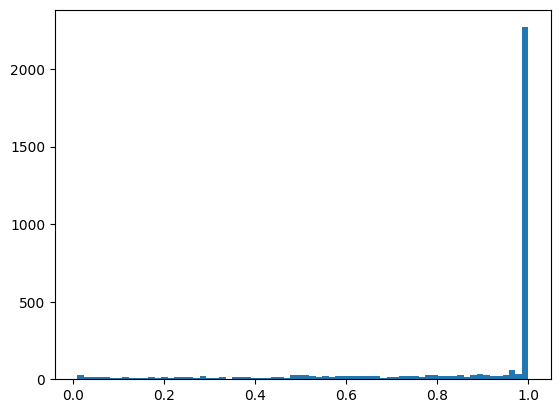

In [ ]:
import matplotlib.pyplot as plt

plt.hist(act_feat[act_feat.target > 0.01].target, bins = 70)

In [ ]:
act_feat.columns

In [ ]:
# Проверка число сезонных признаков
from form_time_features import get_seasonality_features

current_date=pd.to_datetime('2026-04-23')
df_season = get_seasonality_features(current_date)
df_season.head()

In [ ]:
import pandas as pd
import os

# путь к главному файлу
main_file = "data/14 Лимиты мер воздействия ХК.xlsx"

# читаем главный файл
limits_df = pd.read_excel(main_file)

# словарь для результатов
result = {}

for _, row in limits_df.iterrows():
    file_name = row.iloc[0]
    limit = row.iloc[1]

    # пропускаем пустые строки
    if pd.isna(file_name):
        continue

    file_path = os.path.join("data", file_name+".xlsx")

    # читаем файл без заголовков
    df_raw = pd.read_excel(file_path, header=None)

    # 1 строка — название операции
    operation_name = df_raw.iloc[0, 0]

    # 2 строка — заголовки
    df = df_raw.iloc[2:].copy()
    df.columns = df_raw.iloc[1]

    # чистка: убираем #Н/Д
    df = df[df["ЛС"].notna()]

    # сохраняем
    result[operation_name] = {
        "limit": limit,
        "data": df
    }

# теперь result — словарь с данными

In [ ]:
result.keys()

In [ ]:
result["Заявление о выдаче судебного приказа"]

In [ ]:
df2 = pd.read_excel("data/01 Общая информация о ЛС ХК.xlsx", index_col=0)
df2.drop(columns=["Адрес (ГУИД)"], inplace=True)
df2

In [ ]:
from general_information import read_general_information, read_balances, read_actions
from form_time_features import calculate_complex_features
import pandas as pd
# Читаем сальдовую ведомость и удаляем из неё нулевые строки
balances = read_balances()
cols_to_check = balances.columns.drop('ЛС')
balances = balances[(balances[cols_to_check] != 0).any(axis=1)]

# Все другие таблицы должны соответствовать данным id.
ids = balances['ЛС']

# Читаем платёжную таблицу. Удаляем лишние id.
df_pay = pd.read_csv("data/03 Оплаты ХК.csv", sep=";", decimal=",")
df_pay = df_pay[df_pay['Номер'].isin(ids)]

# Читаем информацию с булевыми признаками. Удаляем лишние id.
general_df = read_general_information()
general_df = general_df[general_df['ЛС'].isin(ids)]

actions_df = read_actions()

df = calculate_complex_features(df_pay, balances, 3, pd.Timestamp("2025-04-01"))
df

In [ ]:
df.Current_Debt.value_counts()

In [ ]:
from form_train_set import build_master_dataset

df = build_master_dataset(12)

df

In [ ]:
df.info()